In [1]:
#Импортируем нужные библиотеки 
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
#Загружаем данные 
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_item = pd.read_csv('olist_order_items_dataset.csv')

### Проверяем содержимое  в файлах на типы данных, а также на отсутвие пустых строк 

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [7]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [47]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_delivery_day,order_estimated_day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-10,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-08-07,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-17,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-12-02,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-16,2018-02-26


In [ ]:
orders.dtypes

In [ ]:
orders.isna().sum()

In [ ]:
order_item.head()

In [ ]:
order_item.dtypes

In [8]:
order_item.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

### Оцениваем месячный retention в оформление заказа с помощью когортного анализа

Посмотрим на структуру данных и определим, какие статусы заказов будем учитывать для анализа retention.

In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders.groupby('order_status').order_id.nunique()

order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

Будем рассматривать только заказы со статусом "delivered", исходя из того, что клиент вероятнее всего будет совершать повторные заказы в тех случаях, если не возникнет проблем с покупкой/доставкой первого заказа.

In [11]:
# Переведем все столбцы с датами в формат datetime

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])

In [12]:
# Создаем копию данных, чтобы избежать изменений в исходном DataFrame
customers_copy = customers.copy()
orders_copy = orders.copy()
order_item_copy = order_item.copy()

In [13]:
# В отдельную переменную заносим "customer_id" и "customer_unique_id" для дальнейшего объдинения с customers_copy
customer_unique_id = customers_copy[['customer_id', 'customer_unique_id']]

In [14]:
# Объединим таблицу customer_unique_id и orders по "customer_id"
# Делаем эту операцию для того, чтобы в дальнейшем идентифицировать каждого клиента
#                                                     в таблице orders  по "customer_unique_id"
customers_orders = pd.merge(customer_unique_id, orders_copy, on='customer_id', how='inner')

Для разделения клиентов по когортам будем брать "order_purchase_timestamp", так как датой взаимодействия с маркетплейсом является именно время создания заказа. Столбец "order_approved_at" (время подтверждения оплаты заказа) содержит пустые значения, возможно, у некоторых клиентов возникли проблемы с оплатой, после его создания.

In [15]:
# Извлекаем месяц и день заказа
customers_orders['order_period'] = customers_orders['order_purchase_timestamp'].dt.to_period('M')
customers_orders['order_period_day'] = customers_orders['order_purchase_timestamp'].dt.to_period('D')

In [16]:
# Уберем из датафрейма, ненужные на данном этапе, столбцы и отсортируем по статусу заказа
customers_orders = customers_orders[['customer_id','customer_unique_id','order_id','order_status',\
                                     'order_purchase_timestamp','order_period','order_period_day']]\
                        .query('order_status =="delivered"') #Сортируем по статусу заказа

In [17]:
# Присваиваем когорты на основе даты первого действия для каждого пользователя
customers_orders['cohort'] = customers_orders\
                                .groupby('customer_unique_id')['order_purchase_timestamp']\
                                .transform('min').dt.to_period('M')
customers_orders['cohort_day'] = customers_orders\
                                    .groupby('customer_unique_id')['order_purchase_timestamp']\
                                    .transform('min').dt.to_period('D')

In [18]:
# Рассчитываем номер периода в днях (месячные периоды, делением на 30)
customers_orders['period_number_month'] = np.floor((customers_orders.order_period_day - customers_orders.cohort_day)\
                                          .apply(attrgetter('n')) / 30)

In [19]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = customers_orders.groupby(['cohort', 'period_number_month'])\
            .agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [20]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1


In [21]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [22]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

In [23]:
# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

#### Месячный retention 

In [24]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN
2017-03,1.0,0.002797,0.005194,0.004395,0.001199,0.000799,0.003596,0.001598,0.002397,0.002397,...,0.001598,0.001598,0.001199,0.002797,0.000799,0.001199,0.000799,NaN,NaN,NaN
2017-04,1.0,0.003546,0.002660,0.000443,0.002660,0.003546,0.002660,0.004433,0.002216,0.002660,...,0.001330,NaN,0.000887,0.000887,0.000887,0.000887,NaN,NaN,NaN,NaN
2017-05,1.0,0.004057,0.004057,0.002318,0.003767,0.003187,0.003187,0.001159,0.002898,0.002608,...,0.003187,0.001739,0.000869,0.002028,0.001159,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.004281,0.004939,0.003622,0.001646,0.005268,0.002963,0.001976,0.001317,0.003293,...,0.002963,0.000988,0.002963,0.001317,NaN,NaN,NaN,NaN,NaN,NaN


####  Строим тепловую карту когортного анализа


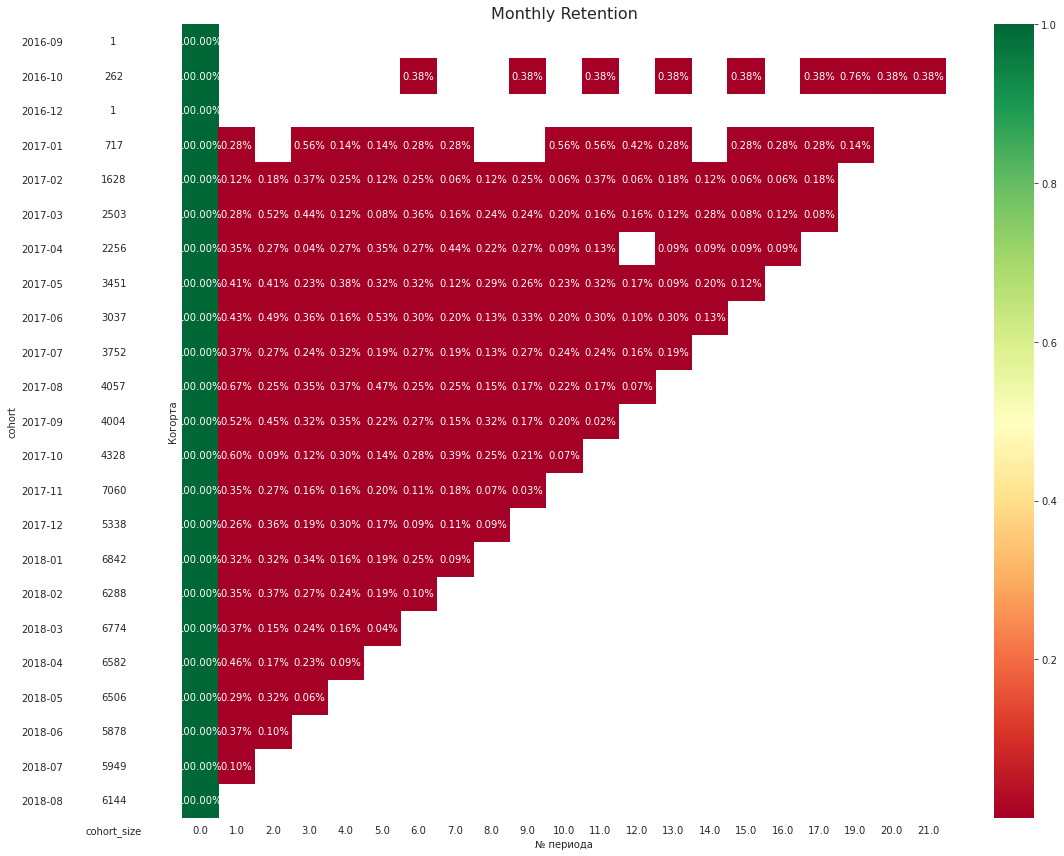

In [27]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

Теперь рассчитаем усредненный retention за первый месяц по всем когортам.

In [28]:
# Усреднённый retention за первый месяц
average_retention_first_month = retention_matrix[1].median()
print(f'Медианный retention за первый месяц: {average_retention_first_month:.4f}')

Медианный retention за первый месяц: 0.0035


In [29]:
# Поиск когорты с самым высоким retention на третий месяц (кохорта с индексом 3)
highest_retention_third_month = retention_matrix[3].idxmax()
highest_retention_value = retention_matrix[3].max()

print(f'Когорта с самым высоким retention на третий месяц: {highest_retention_third_month}, значение: {highest_retention_value:.4f}%')

Когорта с самым высоким retention на третий месяц: 2017-01, значение: 0.0056%


#### Выводы:

По результатам когортного анализа видим низкий уровень удержания клиентов (уже на 1-й месяц retention большинства когорт составляет менее 0.5%) и даже у больших когорт (например, 2018-02 или 2017-11) нет стабильно возвращающихся пользователей.<br>
 

#### Исходя из матрицы когортного анализа данный продукт имеет слабый product/market fit.

Причинами отсутствия PMF могут быть:<br>
 1)низкое качество или цена товаров;<br>
 2)проблемы с доставкой (задержки, отмены);<br>
 3)редкая потребность в товаре.<br>
 
Рекомендации:

1)Сфокусироваться на повышении LTV;<br>
2)Изучить поведение первых покупателей (что они покупали? Какой был срок доставки?);<br>
3)Провести интервью с целью понять, почему клиенты не вернулись. Какие были ожидания? Что не устроило?;<br>
4)A/B‑тесты новых фич для удержания (например, программа лояльности).<br>


#### Построим scatter‑графика зависимости размера когорты от retention на 1-й и 3-й месяц для когорт > 100 клиентов

In [30]:
retention_data = retention_matrix.reset_index()

In [31]:
PMF = pd.merge(cohort_size_df, retention_data, on='cohort', how='inner')

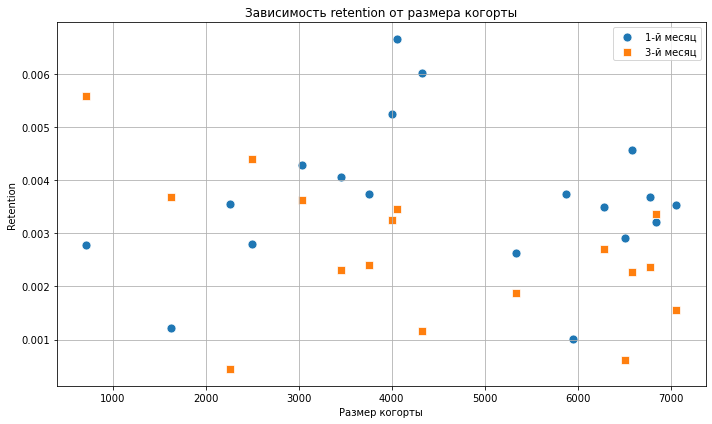

In [32]:
# Фильтруем когорты 
filtered = PMF[PMF['cohort_size'] > 100]

# Построим график зависимости retention на 1-й и 3-й месяц от размера когорты
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=filtered,
    x='cohort_size',
    y=1,  # Retention на 1-й месяц
    label='1-й месяц',
    s=80
)
if 3 in filtered.columns:
    sns.scatterplot(
        data=filtered,
        x='cohort_size',
        y=3,  # Retention на 3-й месяц
        label='3-й месяц',
        s=80,
        marker='s'
    )

plt.title('Зависимость retention от размера когорты')
plt.xlabel('Размер когорты')
plt.ylabel('Retention')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Выводы по графику:
1) Связи между размером когорты и retention нет (большие когорты не гарантируют больший retention);<br>
2) Низкие показатели retention.

###  Определим 5 основных метрик, на которых продукт может сконцентрироваться, чтобы максимизировать прибыль компании.

#### 1) Общий объем продаж (GMV) - показывает общий объём товаров, проданных на маркетплейсе за определенный период

In [33]:
#Будем учитывать цену без учета доставки
GMV = pd.merge(order_item_copy, orders_copy,on='order_id', how='left')
GMV['order_period'] = GMV['order_purchase_timestamp'].dt.to_period('M') 
GMV = GMV.query("order_status =='delivered'")
GMV_by_month = GMV.groupby('order_period')['price'].sum().reset_index()
GMV_by_month['order_period'] = GMV_by_month['order_period'].astype(str)

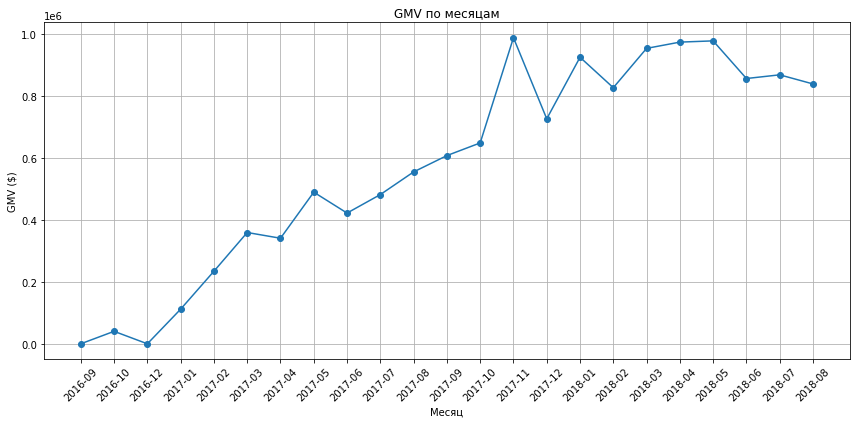

In [34]:
# Визуализируем GMV
plt.figure(figsize=(12, 6))
plt.plot(GMV_by_month['order_period'], GMV_by_month['price'], marker='o')
plt.xticks(rotation=45)
plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2) Количество платящих клиентов (Paying Users)

In [35]:
paying_users = GMV.query("order_status =='delivered'").groupby('order_period')['customer_id'].nunique().reset_index()
paying_users['order_period'] = paying_users['order_period'].astype(str)
paying_users.rename(columns={'customer_id': 'paying_users'}, inplace=True)

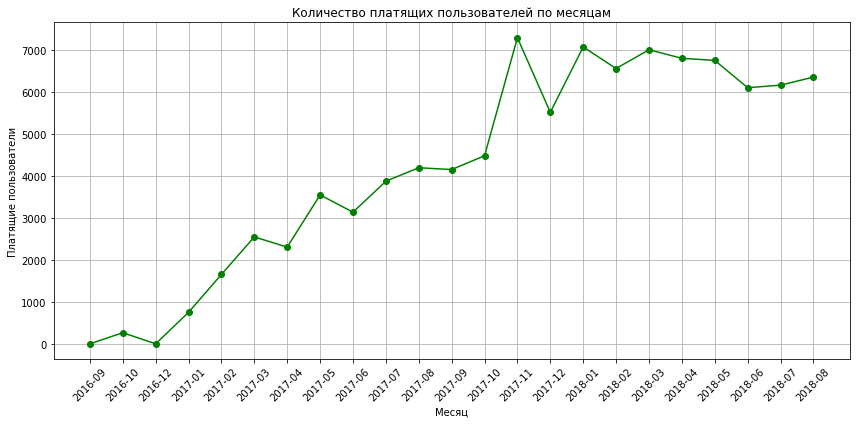

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(paying_users['order_period'], paying_users['paying_users'], marker='o', color='green')
plt.title('Количество платящих пользователей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Платящие пользователи')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3) Повторные заказы среди новых клиентов: если клиент делает второй заказ в течение 30–60 дней, это может говорить о заинтересованности
#### 4) Retention Rate — возврат пользователей (доля пользователей, совершивших повторную покупку через месяц после первой покупки на маркетплейсе)
#### 5) ARPPU — Average Revenue Per User (средняя выручка на одного пользователя)
Выбирал между ARPPU от ARPU, но по итогу решил взять среднюю выручку на одного пользователя, нежели среднюю выручку на одного платящего клиента.Построим график ARPPU.

In [37]:
revenue_per_mounth = GMV.merge(customer_unique_id, on='customer_id') #customer_unique_id взял из первого шага

ARPPU_metric = revenue_per_mounth.groupby('order_period').agg(
    sum_revenue=('price', 'sum'),
    paying_customer=('customer_unique_id', 'nunique')).reset_index()

ARPPU_metric['ARRPU'] =  (ARPPU_metric['sum_revenue'] / ARPPU_metric['paying_customer']).round(2)

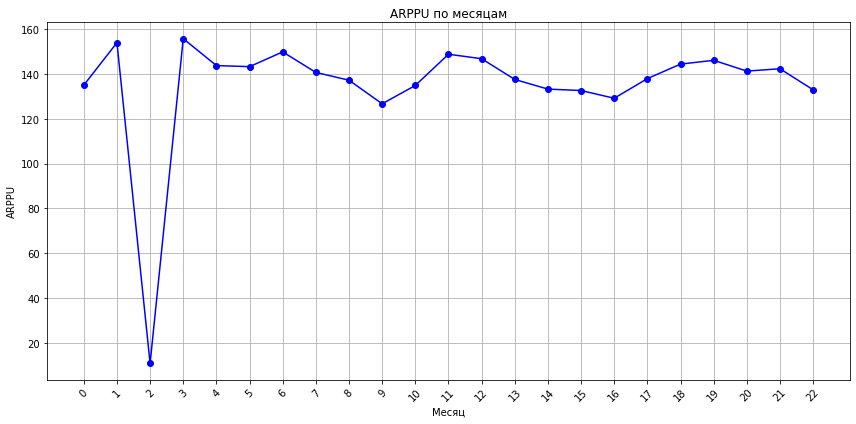

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(ARPPU_metric.index.astype(str), ARPPU_metric['ARRPU'], marker='o', color='blue')
plt.title('ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выбираем одну из 3 основных гипотез с помощью фреймворка ICE.

**Гипотеза 1**:Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. <br>
Confidence - 8 Ease - 6 <br>
**Гипотеза 2**: Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. <br>
Confidence - 10 Ease - 4 <br>
**Гипотеза 3**: Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.<br>
Confidence - 5 Ease - 9 <br>

Для расчета Impact по этой **гипотезы 1** можно посчитать количество заказов, который остались в статусе отмены. Заказом в статусе отмены будем считать статусы: canceled, unavailable

In [41]:
#Извлекаем месяц заказа
orders_copy['order_mounth'] = orders_copy['order_purchase_timestamp'].dt.to_period('M')

In [ ]:
#Посчитаем количество отмененных заказов (unavailable и canceled) с июня 2017 года.
orders_copy.query('order_mounth >="2017-06" & order_status =="unavailable" or order_status =="canceled"')

In [42]:
canceled_count = orders_copy.query('order_mounth >="2017-06" & order_status =="unavailable" or order_status =="canceled"')\
                            .order_id.count()
# Impact будет равен количеству заказов
print(f'Количество отмененных заказов (со статусом unavailable и canceled ) с  июня 2017 года : {canceled_count}')

Количество отмененных заказов (со статусом unavailable и canceled ) с  июня 2017 года : 1100


Для расчета Impact по **гипотезе 2** можно посчитать количество заказов, которые были доставлены с опозданием. Конверсию в повторный заказ возьмем равной 0.0035.

In [48]:
#Посчитаем количество заказов, доставленных с опозданием 
delayed_delivery = orders_copy\
        .query('order_mounth >="2017-06" & order_status=="delivered" & order_estimated_delivery_date <= order_delivered_customer_date ')\
            .order_id.count()

In [49]:
# Impact будет равен произведению количества заказов, доставленных с опозданием на конверсию в повторный заказ (0.0035)
print(f'Количество заказов ,доставленных с опозданием с  июня 2017 года : {delayed_delivery}. Impact равняется : {delayed_delivery*0.0035:.2f}')

Количество заказов ,доставленных с опозданием с  июня 2017 года : 7295. Impact равняется : 25.53


Для расчета Impact по **гипотезе 3**  можно посчитать количество заказов, где клиент сделал только единичный заказ. Конверсию в повторный заказ возьмем равной 0.0035.

In [51]:
customer_orders = pd.merge(customer_unique_id, orders_copy, on='customer_id', how='inner')
customer_orders.head()

,customer_id,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_mounth
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07


In [52]:
# подсчитываем количество заказов для каждого клиента
customer_order_counts = customer_orders[(customer_orders.order_mounth >= '2017-06')].groupby('customer_unique_id').order_id.nunique().reset_index()

# определяем количество клиентов, которые сделали только один заказ
single_order_customers_count = (customer_order_counts == 1).order_id.sum()

In [53]:
print(f'Количество задержанных заказов: {single_order_customers_count}')
print(f'Возможное количество повторных заказов: {single_order_customers_count*0.0035}')

Количество задержанных заказов: 82559
Возможное количество повторных заказов: 288.9565


### Вывод:  
гипотеза 1: Impact = 5,<br>
гипотеза 2: Impact =1,<br> 
гипотеза 3: Impact =3<br>
ICE для первой гипотезы - 240 <br>
ICE для первой гипотезы - 40<br>
ICE для первой гипотезы - 135 <br>

####  Выигрывает гипотеза 1 -  если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. 

### Сформулируем нужные метрики, на которые выбранная гипотеза должна повлиять.

Гипотеза: если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. Метрики можно разделить на три категории: целевые, прокси и guardrail.

**Целевые метрики**: 

Доля доставленных заказов. Поможет нам определить, изменится ли доля доставленных заказов после исправления бага.

**Прокси метрики**: 

Доля отменённых заказов.Снижение отмен подтверждает, что баг устранён и клиенты больше не сталкиваются с отменами доставок.

**Guardrail метрики**:

Уровень возвратов, чтобы исправление багов  не привёл к увеличению количества возвратов.

### Выводы о проделанной работе

Несмотря на стабильный приток новых пользователей, выручка маркетплейса остаётся на одном уровне. Это связано с тем, что большинство клиентов не возвращаются в последующие месяцы, что говорит о низкой воспринимаемой ценности продукта. Пользователи не видят достаточной мотивации, чтобы совершать повторные покупки, а значит — продукт пока не стал для них действительно полезным или незаменимым. 

Мы выбрали и рассчитали 5 метрик, на которые стоит ориентироваться:

GMV (объём продаж) — показывает размер бизнеса;

Количество платящих клиентов;

Повторные заказы среди новых клиентов

Retention, который  отражает, насколько клиент остаётся в продуктом;

ARPPU — сколько денег приносит один платящий клиент.

Выяснили, что общий объем продаж не растет уже несколько месяцев, как и количество платящих пользователей. Это говорит о том, что выручка формируется в основном за счет новый клиентов, которые совершают покупки, но при этом старые клиенты не возвращаются в продукт. 



Мы предлагаем в первую очередь сконцентрироваться на исправлении програмных ошибок при оформлении заказов для снижения количества отмен. Это должно повысить долю доставленных заказов и стимулировать клиента на повторный заказ

Для проверки гипотезы необходимо отслеживать слудующие метрики: доля доставленных заказов, конверсия в доставку, возвраты — чтобы убедиться, что мы ничего не ухудшили.

Рекомендации по продукту:
1) Сконцентрироваться на удержании клиентов:
        - Разработать систему мотивации к повторному заказу (бонусы, рассылки, рекомендации);
        - Отслеживать качество доставки, т.к. баги и просрочки могут сильно портить впечатление;
        - Исправить баги в процессе заказов;

2) Продолжить улучшать клиентский опыт:
        - Проверить воронку покупки, точки отказа, поведение в первые дни после заказа;
        - Возможно, стоит улучшить видимость товара, фильтры, категории.

